In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/content/network_data.csv')
df

,timestamp,region,latency_ms,packet_loss_%,throughput_mbps,network_type
0,2022-01-01 00:00:00,East,53.417560,3.183348,68.037513,4G
1,2022-01-01 01:00:00,West,68.761708,3.069668,109.243453,4G
2,2022-01-01 02:00:00,North,59.504238,0.333260,140.486192,4G
3,2022-01-01 03:00:00,East,44.230963,2.592040,72.736520,4G
4,2022-01-01 04:00:00,East,41.015853,0.750845,103.794123,4G
...,...,...,...,...,...,...
995,2022-02-11 11:00:00,North,45.120886,4.218248,126.611498,4G
996,2022-02-11 12:00:00,North,71.573082,4.905963,76.064227,5G
997,2022-02-11 13:00:00,West,43.942851,3.965714,117.873954,4G
998,2022-02-11 14:00:00,West,57.420954,4.268925,117.859077,4G


In [8]:
df.shape

(1000, 6)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   timestamp        1000 non-null   object 
 1   region           1000 non-null   object 
 2   latency_ms       1000 non-null   float64
 3   packet_loss_%    1000 non-null   float64
 4   throughput_mbps  1000 non-null   float64
 5   network_type     1000 non-null   object 
dtypes: float64(3), object(3)
memory usage: 47.0+ KB


In [4]:
print(df.describe())

        latency_ms  packet_loss_%  throughput_mbps
count  1000.000000    1000.000000      1000.000000
mean     50.401664       2.478899        99.860576
std      10.012925       1.441342        19.763733
min      21.037446       0.000673        40.177281
25%      43.749954       1.295639        86.785272
50%      50.366335       2.490170        99.740733
75%      56.815984       3.738008       113.024654
max      80.788808       4.991738       178.524754


In [10]:
df.isnull().sum()

,0
timestamp,0
region,0
latency_ms,0
packet_loss_%,0
throughput_mbps,0
network_type,0


In [11]:
#Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [5]:
# Avg latency by region
df.groupby('region')['latency_ms'].mean()

,latency_ms
region,
East,50.652042
North,50.290689
South,50.749158
West,50.011022


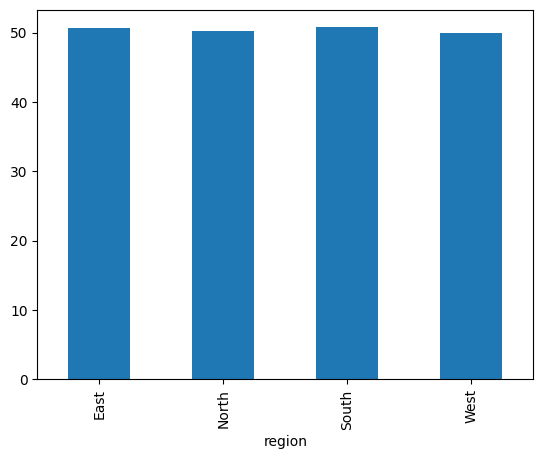

In [6]:
#Visualization
df.groupby('region')['latency_ms'].mean().plot(kind='bar')
plt.show()

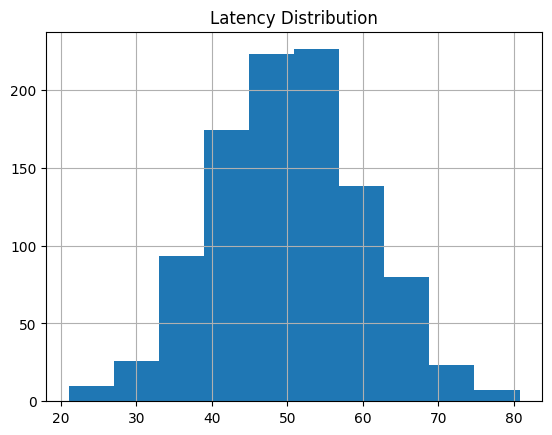

In [12]:
#KPI Distribution

df['latency_ms'].hist()
plt.title("Latency Distribution")
plt.show()

In [13]:
#4G vs 5G Comparison
df.groupby('network_type')[['latency_ms','throughput_mbps']].mean()

,latency_ms,throughput_mbps
network_type,,
4G,49.827190,99.804346
5G,50.985404,99.917712


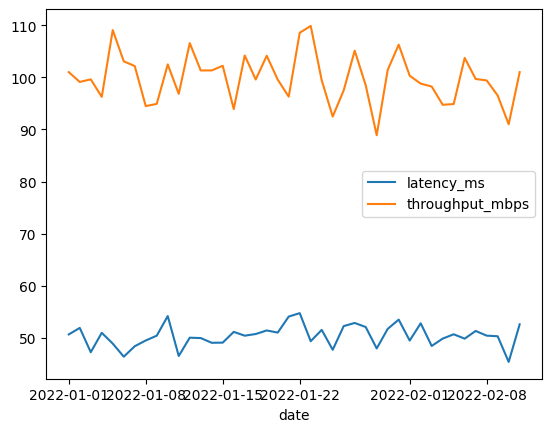

In [14]:
#Daily trend
df['date'] = df['timestamp'].dt.date
df.groupby('date')[['latency_ms','throughput_mbps']].mean().plot()
plt.show()

In [15]:
#Correlation Analysis
df[['latency_ms','packet_loss_%','throughput_mbps']].corr()

,latency_ms,packet_loss_%,throughput_mbps
latency_ms,1.000000,-0.026151,0.032174
packet_loss_%,-0.026151,1.000000,-0.051392
throughput_mbps,0.032174,-0.051392,1.000000


- Higher latency observed in certain regions indicating possible congestion
- Peak latency occurs during specific hours suggesting traffic load impact
- 5G networks provide better throughput and lower latency than 4G
- Increased packet loss negatively impacts throughput